In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/__results__.html
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/__notebook__.ipynb
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/__output__.json
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/tfidf.pkl
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/custom.css
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/repo/README.md
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/repo/DL-24f2001460-notebook-t22026.ipynb
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/repo/models/tfidf.py
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/repo/models/scratch.py
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/repo/models/__pycache__/tfidf.cpython-312.pyc
/kaggle/input/notebooks/jigyasadoharey/tfidf-model/repo/wandb/run-20

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("new_token")


In [3]:
!git clone https://{secret_value_0}@github.com/24f2001460/dl-24f2001460-notebook-t22026.git /kaggle/working/repo1
%cd /kaggle/working/repo1

Cloning into '/kaggle/working/repo1'...
remote: Enumerating objects: 204, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 204 (delta 106), reused 136 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (204/204), 214.44 KiB | 2.55 MiB/s, done.
Resolving deltas: 100% (106/106), done.
/kaggle/working/repo1


# Quick EDA


In [4]:
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print("train shape:", train.shape)
print("test shape:", test.shape)

train.head()

train shape: (2000, 8)
test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## Checking for missing values and how balanced the answers are

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


<Axes: title={'center': 'Answer distribution'}, xlabel='answer'>

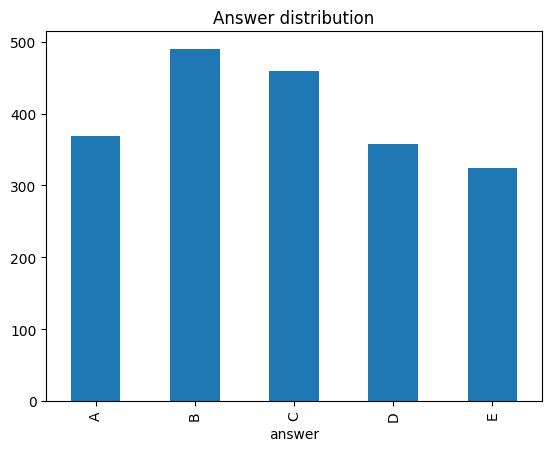

In [5]:
print(train.isnull().sum())
print()
print(train['answer'].value_counts())

train['answer'].value_counts().sort_index().plot(kind='bar', title='Answer distribution')

## Checking how long the questions and options are on average

avg prompt length: 117.6695


<Axes: title={'center': 'Prompt length distribution'}, ylabel='Frequency'>

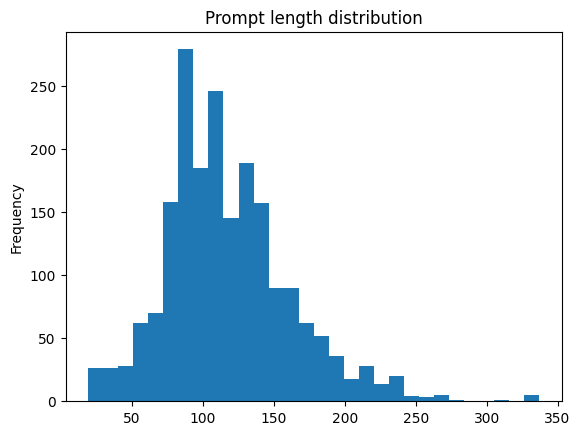

In [6]:
print("avg prompt length:", train['prompt'].str.len().mean())
train['prompt'].str.len().plot(kind='hist', bins=30, title='Prompt length distribution')

## Answer column distribution

In [7]:
print(train['answer'].value_counts())
print(f"\nAnswer % :\n{(train['answer'].value_counts(normalize=True)*100).round(2)}")

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Answer % :
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64


## Visualization of Answer Column

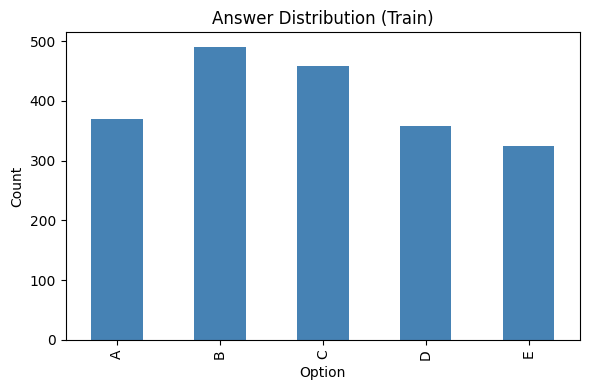

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
train['answer'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Answer Distribution (Train)")
plt.xlabel("Option")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Prompt length distribution


Average option length (words):
 A_len    26.1460
B_len    26.5160
C_len    26.5495
D_len    25.9995
E_len    26.1870
dtype: float64


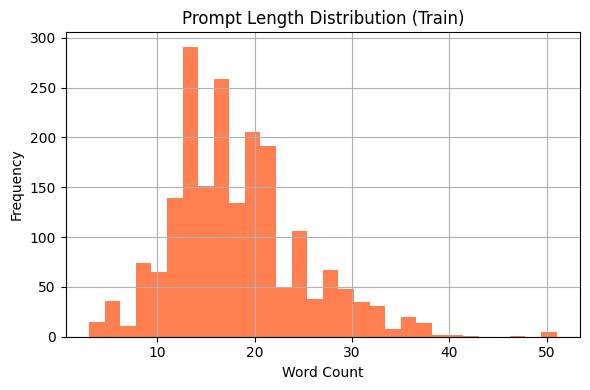

In [9]:
for opt in ['A','B','C','D','E']:
    train[f'{opt}_len'] = train[opt].astype(str).str.split().str.len()
avg_opt_len = train[['A_len','B_len','C_len','D_len','E_len']].mean()
print("\nAverage option length (words):\n", avg_opt_len)

plt.figure(figsize=(6,4))
train['prompt_len'] = train['prompt'].astype(str).str.split().str.len()
train['prompt_len'].hist(bins=30, color='coral')
plt.title("Prompt Length Distribution (Train)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Logistic Regression TFIDF Based Model_1

In [10]:
# train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
# test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

## Converting each question into 5 rows

In [11]:
# rows = []

# options = ['A', 'B', 'C', 'D', 'E']

# for _, row in train.iterrows():

#     prompt = row['prompt']
#     correct = row['answer']

#     for opt in options:

#         text = prompt + ' [SEP] ' + str(row[opt])

#         label = 1 if opt == correct else 0

#         rows.append({
#             'text': text,
#             'label': label,
#             'option': opt
#         })

# new_train = pd.DataFrame(rows)

# print(new_train)

## Splitting into train and validation sets

In [12]:
# from sklearn.model_selection import train_test_split

# X_train, X_valid, y_train, y_valid = train_test_split(
#     new_train['text'],
#     new_train['label'],
#     test_size=0.2,
#     random_state=42
# )

## Converting the text into tfidf features

In [13]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(
#     max_features=20000,
#     ngram_range=(1,2),
#     stop_words='english'
# )

# X_train_tfidf = vectorizer.fit_transform(X_train)
# X_valid_tfidf = vectorizer.transform(X_valid)

## Training a logistic regression model

In [14]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(class_weight='balanced')

# model.fit(X_train_tfidf, y_train)

## Checking accuracy

In [15]:
# from sklearn.metrics import accuracy_score

# preds = model.predict(X_valid_tfidf)

# acc = accuracy_score(y_valid, preds)

# print(acc)

## Doing the same row-expansion for the test data

In [16]:
# test_rows = []

# for _, row in test.iterrows():

#     prompt = row['prompt']

#     for opt in options:

#         text = prompt + ' [SEP] ' + str(row[opt])

#         test_rows.append({
#             'id': row['id'],
#             'text': text,
#             'option': opt
#         })

# new_test = pd.DataFrame(test_rows)

## Getting probability scores for each option on test data

In [17]:
# X_test_tfidf = vectorizer.transform(new_test['text'])

# probs = model.predict_proba(X_test_tfidf)[:,1]

# new_test['prob'] = probs

## Creating submission

In [18]:
# final_predictions = []

# for qid in new_test['id'].unique():

#     temp = new_test[new_test['id'] == qid]

#     temp = temp.sort_values(by='prob', ascending=False)

#     top3 = temp['option'].values[:3]

#     prediction = ' '.join(top3)

#     final_predictions.append({
#         'id': qid,
#         'prediction': prediction
#     })

# submission = pd.DataFrame(final_predictions)

# print(submission.head())

# submission.to_csv('submission.csv', index=False)

# TF-IDF INFERENCE

In [19]:
!python -m src.tfidf_inference\
    --test_path  /kaggle/input/competitions/smart-mcq-solver-challenge/test.csv \
    --model_path  /kaggle/input/notebooks/jigyasadoharey/tfidf-model/tfidf.pkl \
    --output_path /kaggle/working/submission.csv

/kaggle/working/repo1/src/tfidf_inference.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = expanded.groupby('id').apply(rank_options).reset_index()
Saved 500 predictions to /kaggle/working/submission.csv


# Bi-Lstm Scratch Model_2

In [20]:
# import pandas as pd
# import numpy as np
# import re

# from sklearn.model_selection import train_test_split

# import torch
# import torch.nn as nn

# from torch.utils.data import Dataset, DataLoader

# from collections import Counter

# device = torch.device(
#     "cuda" if torch.cuda.is_available() else "cpu"
# )

# print("DEVICE:", device)

In [21]:
# train = pd.read_csv(
#     '/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv'
# )

# test = pd.read_csv(
#     '/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv'
# )

## Simple text cleaning function

In [22]:
# def clean_text(text):

#     text = str(text).lower()

#     text = re.sub(r'[^a-z0-9 ]', ' ', text)

#     text = re.sub(r'\s+', ' ', text)

#     return text.strip()

## Building training pairs

In [23]:
# rows = []

# options = ['A', 'B', 'C', 'D', 'E']

# for _, row in train.iterrows():

#     prompt = clean_text(row['prompt'])

#     correct = row['answer']

#     for opt in options:

#         option_text = clean_text(row[opt])

#         text = (
#             "question " + prompt +
#             " answer " + option_text
#         )

#         label = 1 if opt == correct else 0

#         rows.append({

#             'text': text,

#             'label': label
#         })

# new_train = pd.DataFrame(rows)

# print(new_train.head())

## Train-validation split

In [24]:
# X_train, X_valid, y_train, y_valid = train_test_split(

#     new_train['text'],

#     new_train['label'],

#     test_size=0.2,

#     random_state=42,

#     stratify=new_train['label']


## Building vocabulary 

In [25]:
# MAX_WORDS = 30000

# counter = Counter()

# for text in X_train:

#     counter.update(text.split())

# most_common = counter.most_common(MAX_WORDS - 2)

# word2idx = {

#     "<PAD>": 0,

#     "<UNK>": 1
# }

# for idx, (word, _) in enumerate(most_common, start=2):

#     word2idx[word] = idx

# vocab_size = len(word2idx)

# print("VOCAB SIZE:", vocab_size)

## Encoding the text

In [26]:
# MAX_LEN = 128

# def encode_text(text):

#     tokens = text.split()

#     seq = []

#     for token in tokens:

#         seq.append(

#             word2idx.get(token, 1)
#         )

#     seq = seq[:MAX_LEN]

#     while len(seq) < MAX_LEN:

#         seq.append(0)

#     return seq

# X_train_seq = np.array([

#     encode_text(text)

#     for text in X_train
# ])

# X_valid_seq = np.array([

#     encode_text(text)

#     for text in X_valid
# ])

## Loading the sequence

In [27]:
# class MCQDataset(Dataset):

#     def __init__(self, X, y):

#         self.X = torch.tensor(

#             X,

#             dtype=torch.long
#         )

#         self.y = torch.tensor(

#             y.values,

#             dtype=torch.float32
#         )

#     def __len__(self):

#         return len(self.X)

#     def __getitem__(self, idx):

#         return self.X[idx], self.y[idx]

## Creating train and validation datasets

In [28]:
# train_dataset = MCQDataset(

#     X_train_seq,

#     y_train
# )

# valid_dataset = MCQDataset(

#     X_valid_seq,

#     y_valid
# )

# train_loader = DataLoader(

#     train_dataset,

#     batch_size=64,

#     shuffle=True
# )

# valid_loader = DataLoader(

#     valid_dataset,

#     batch_size=64
# )


## Adding attention layer

In [29]:
# class Attention(nn.Module):

#     def __init__(self, hidden_dim):

#         super().__init__()

#         self.attention = nn.Linear(

#             hidden_dim * 2,

#             1
#         )

#     def forward(self, x):

#         weights = torch.softmax(

#             self.attention(x),

#             dim=1
#         )

#         output = torch.sum(

#             x * weights,

#             dim=1
#         )

#         return output

## Loading the bilstm model with attention

In [30]:
# class StrongMCQModel(nn.Module):

#     def __init__(self):

#         super().__init__()

#         # EMBEDDING

#         self.embedding = nn.Embedding(

#             vocab_size,

#             256,

#             padding_idx=0
#         )

#         # CNN

#         self.conv1 = nn.Conv1d(

#             256,

#             128,

#             kernel_size=3,

#             padding=1
#         )

#         # BiLSTM

#         self.lstm = nn.LSTM(

#             input_size=128,

#             hidden_size=128,

#             batch_first=True,

#             bidirectional=True,

#             dropout=0.3
#         )

#         # ATTENTION

#         self.attention = Attention(128)

#         # DROPOUT

#         self.dropout = nn.Dropout(0.3)

#         # FC

#         self.fc1 = nn.Linear(

#             256,

#             128
#         )

#         self.relu = nn.ReLU()

#         self.fc2 = nn.Linear(

#             128,

#             1
#         )

#     def forward(self, x):

#         # EMBEDDING

#         x = self.embedding(x)

#         # CNN

#         x = x.permute(0, 2, 1)

#         x = self.conv1(x)

#         x = torch.relu(x)

#         x = x.permute(0, 2, 1)

#         # LSTM

#         x, _ = self.lstm(x)

#         # ATTENTION

#         x = self.attention(x)

#         # DROPOUT

#         x = self.dropout(x)

#         # FC

#         x = self.fc1(x)

#         x = self.relu(x)

#         x = self.dropout(x)

#         x = self.fc2(x)

#         return x.squeeze()

In [31]:
# model = StrongMCQModel().to(device)

# print(model)


## Loss function

In [32]:
# criterion = nn.BCEWithLogitsLoss()


## Optimizer setup

In [33]:
# optimizer = torch.optim.AdamW(

#     model.parameters(),

#     lr=0.001,

#     weight_decay=1e-5
# )

## Learning rate scheduler

In [34]:
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

#     optimizer,

#     mode='max',

#     patience=1,

#     factor=0.5
# )


## Training loop 

In [35]:
# EPOCHS = 15

# best_acc = 0

# for epoch in range(EPOCHS):

#     # =========================
#     # TRAIN
#     # =========================

#     model.train()

#     train_correct = 0

#     train_total = 0

#     train_loss = 0

#     for X_batch, y_batch in train_loader:

#         X_batch = X_batch.to(device)

#         y_batch = y_batch.to(device)

#         optimizer.zero_grad()

#         outputs = model(X_batch)

#         loss = criterion(

#             outputs,

#             y_batch
#         )

#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(

#             model.parameters(),

#             1.0
#         )

#         optimizer.step()

#         train_loss += loss.item()

#         preds = torch.sigmoid(outputs)

#         preds = (preds > 0.5).float()

#         train_correct += (

#             preds == y_batch
#         ).sum().item()

#         train_total += y_batch.size(0)

#     train_acc = train_correct / train_total

#     # =========================
#     # VALIDATION
#     # =========================

#     model.eval()

#     val_correct = 0

#     val_total = 0

#     val_loss = 0

#     with torch.no_grad():

#         for X_batch, y_batch in valid_loader:

#             X_batch = X_batch.to(device)

#             y_batch = y_batch.to(device)

#             outputs = model(X_batch)

#             loss = criterion(

#                 outputs,

#                 y_batch
#             )

#             val_loss += loss.item()

#             preds = torch.sigmoid(outputs)

#             preds = (preds > 0.5).float()

#             val_correct += (

#                 preds == y_batch
#             ).sum().item()

#             val_total += y_batch.size(0)

#     val_acc = val_correct / val_total

#     scheduler.step(val_acc)

#     print(

#         f"Epoch {epoch+1}"

#         f" | Train Loss: {train_loss:.4f}"

#         f" | Train Acc: {train_acc:.4f}"

#         f" | Val Loss: {val_loss:.4f}"

#         f" | Val Acc: {val_acc:.4f}"
#     )


## Same for test data

In [36]:
# test_rows = []

# for _, row in test.iterrows():

#     prompt = clean_text(row['prompt'])

#     for opt in options:

#         option_text = clean_text(row[opt])

#         text = (

#             "question " + prompt +

#             " answer " + option_text
#         )

#         test_rows.append({

#             'id': row['id'],

#             'text': text,

#             'option': opt
#         })

# new_test = pd.DataFrame(test_rows)

In [37]:
# X_test_seq = np.array([

#     encode_text(text)

#     for text in new_test['text']
# ])

# X_test_tensor = torch.tensor(

#     X_test_seq,

#     dtype=torch.long
# )

# test_loader = DataLoader(

#     X_test_tensor,

#     batch_size=64
# )

## Running the model on test data to get probabilities

In [38]:
# model.eval()

# all_probs = []

# with torch.no_grad():

#     for X_batch in test_loader:

#         X_batch = X_batch.to(device)

#         outputs = model(X_batch)

#         probs = torch.sigmoid(outputs)

#         all_probs.extend(

#             probs.cpu().numpy()
#         )

# new_test['prob'] = all_probs

## Creating submission

In [39]:
# final_predictions = []

# for qid in new_test['id'].unique():

#     temp = new_test[

#         new_test['id'] == qid
#     ]

#     temp = temp.sort_values(

#         by='prob',

#         ascending=False
#     )

#     top3 = temp['option'].values[:3]

#     prediction = ' '.join(top3)

#     final_predictions.append({

#         'id': qid,

#         'prediction': prediction
#     })

# submission = pd.DataFrame(final_predictions)

# print(submission.head())

In [40]:

# submission.to_csv(

#     'submission.csv',

#     index=False)

# SCRATCH_INFERENCE

In [41]:
# !python -m src.scratch_inference\
#     --test_path  /kaggle/input/competitions/smart-mcq-solver-challenge/test.csv \
#     --model_path  /kaggle/input/notebooks/jigyasadoharey/scratch-model/repo/model.pt\
#     --vocab_path /kaggle/input/notebooks/jigyasadoharey/scratch-model/repo/word2idx.pkl\
#     --output_path /kaggle/working/submission.csv

# Qwen2.5-7B Pretrained Model_3

## Imported the required libraries and loaded the Qwen2.5-7B-Instruct model and prepared the Kaggle datasets for QLoRA fine-tuning.

In [42]:
# import numpy as np
# !pip install -q -U bitsandbytes>=0.46.1
# import pandas as pd
# import torch
# import os
# import wandb
# from datasets import Dataset
# from transformers import (
#     AutoTokenizer,
#     AutoModelForCausalLM,
#     BitsAndBytesConfig,
#     TrainingArguments,
#     Trainer,
#     DataCollatorForSeq2Seq,
# )
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# try:
#     from kaggle_secrets import UserSecretsClient
#     wandb_key = UserSecretsClient().get_secret("wandb_key")
# except Exception:
#     wandb_key = os.environ.get("wandb_key")

# wandb.login(key=wandb_key)
# wandb.init(project="24f2001460-t22026", name="qwen2.5-7b-qlora-mc")

# MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
# MAX_LEN = 512
# OPTIONS = ["A", "B", "C", "D", "E"]

# train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


## Loaded the tokenizer and Qwen2.5-7B model, applied QLoRA configuration, and prepared option token IDs for multiple-choice training.


In [43]:
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# tokenizer.pad_token = tokenizer.eos_token
# tokenizer.padding_side = "right"

# model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     quantization_config=bnb_config,
#     device_map="auto",
# )
# model = prepare_model_for_kbit_training(model)

# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
# )
# model = get_peft_model(model, lora_config)

# OPTION_TOKEN_IDS = {o: tokenizer.encode(o, add_special_tokens=False)[0] for o in OPTIONS}


## Configured quantization with BitsAndBytes to reduce memory usage and enable efficient QLoRA fine-tuning.

In [44]:
# import numpy as np
# !pip install -q -U bitsandbytes>=0.46.1
# import pandas as pd
# import torch
# import os
# import wandb
# from datasets import Dataset
# from transformers import (
#     AutoTokenizer,
#     AutoModelForCausalLM,
#     BitsAndBytesConfig,
#     TrainingArguments,
#     Trainer,
#     DataCollatorForSeq2Seq,
# )
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# try:
#     from kaggle_secrets import UserSecretsClient
#     wandb_key = UserSecretsClient().get_secret("wandb_key")
# except Exception:
#     wandb_key = os.environ.get("wandb_key")

# wandb.login(key=wandb_key)
# wandb.init(project="24f2001460-t22026", name="qwen2.5-7b-qlora-mc")

# MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
# MAX_LEN = 512
# OPTIONS = ["A", "B", "C", "D", "E"]

# train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.bfloat16,
#     bnb_4bit_use_double_quant=True,
# )


## Prepared the training dataset, configured the training settings, fine-tuned the Qwen model using the Hugging Face Trainer

In [45]:
# def build_prompt(row):
#     return (
#         f"Question: {row['prompt']}\n"
#         f"A. {row['A']}\n"
#         f"B. {row['B']}\n"
#         f"C. {row['C']}\n"
#         f"D. {row['D']}\n"
#         f"E. {row['E']}\n"
#         f"Answer:"
#     )

# def preprocess_train(examples):
#     input_ids_list, labels_list, attn_list = [], [], []
#     for i in range(len(examples["prompt"])):
#         row = {k: examples[k][i] for k in examples}
#         prompt = build_prompt(row)
#         full_text = prompt + " " + row["answer"]

#         prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
#         full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]
#         full_ids = full_ids[:MAX_LEN]

#         labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
#         labels = labels[:MAX_LEN]

#         attn = [1] * len(full_ids)

#         input_ids_list.append(full_ids)
#         labels_list.append(labels)
#         attn_list.append(attn)

#     return {"input_ids": input_ids_list, "labels": labels_list, "attention_mask": attn_list}

# train_dataset = Dataset.from_pandas(train_df)
# train_dataset = train_dataset.map(
#     preprocess_train, batched=True, remove_columns=train_df.columns.tolist()
# )

# split = train_dataset.train_test_split(test_size=0.1, seed=42)
# train_ds, val_ds = split["train"], split["test"]

# data_collator = DataCollatorForSeq2Seq(
#     tokenizer=tokenizer, padding=True, label_pad_token_id=-100
# )

# args = TrainingArguments(
#     output_dir="/kaggle/working/mcq_qwen_output",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-4,
#     per_device_train_batch_size=1,
#     per_device_eval_batch_size=1,
#     gradient_accumulation_steps=16,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     warmup_ratio=0.05,
#     bf16=True,
#     optim="paged_adamw_8bit",
#     report_to="wandb",
#     logging_steps=10,
#     save_total_limit=1,
#     load_best_model_at_end=True,
# )

# trainer = Trainer(
#     model=model,
#     args=args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     processing_class=tokenizer,
#     data_collator=data_collator,
# )

# trainer.train()

# model.eval()
# option_ids_tensor = torch.tensor([OPTION_TOKEN_IDS[o] for o in OPTIONS])


## Generated the top-3 answer predictions for the test set

In [46]:
# def predict_top3(row):
#     prompt = build_prompt(row) + " "
#     inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
#     with torch.no_grad():
#         logits = model(**inputs).logits[0, -1]
#     option_logits = logits[option_ids_tensor.to(model.device)]
#     probs = torch.softmax(option_logits, dim=0).float().cpu().numpy()
#     top3_idx = np.argsort(-probs)[:3]
#     return " ".join(OPTIONS[i] for i in top3_idx)

# test_ids = test_df["id"].tolist()
# predictions = [predict_top3(row) for _, row in test_df.iterrows()]

# submission = pd.DataFrame({"id": test_ids, "Prediction": predictions})
# submission.to_csv("submission.csv", index=False)

# wandb.finish()

# PRETRAINED_INFERENCE

In [47]:
# ## !python -m src.pretrained_inference\
#     --test_path  /kaggle/input/competitions/smart-mcq-solver-challenge/test.csv \
#     --adapter_path  /kaggle/input/notebooks/jigyasadoharey/pretrained-model/mcq_qwen_output/checkpoint-339 \
#     --output_path /kaggle/working/submission.csv